In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Configurações padrão para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

# Carregar o dataset
try:
  path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

  df_performance = pd.read_csv(path+"/StudentsPerformance.csv")
    # Renomear colunas para facilitar o uso
  df_performance.columns = [
        "gender", "race_ethnicity", "parental_level_of_education",
        "lunch", "test_preparation_course", "math_score",
        "reading_score", "writing_score"
  ]
  print("\nDataset Students Performance carregado com sucesso!")
  print(df_performance.head())
  print("\nInformações do Dataset:")
  df_performance.info()
except FileNotFoundError:
  print("Erro: 'StudentsPerformance.csv' não encontrado.")


print("\nPré-processamento básico concluído.")

C:\Users\d6684\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliotecas importadas e configurações aplicadas!

Dataset Students Performance carregado com sucesso!
   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Informações do Dataset:
<class 'pandas.core.frame.DataF

In [3]:
df_performance.head

<bound method NDFrame.head of      gender race_ethnicity parental_level_of_education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test_preparation_course  math_score  reading_score  writing_score  
0                      none      

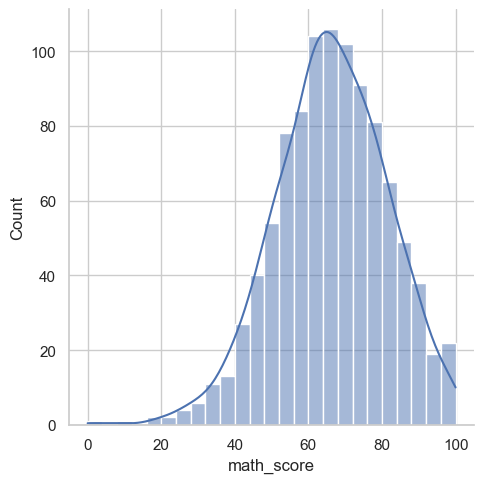

In [ ]:
#Principio data-ink ratio, uso de linhas para suavizar
#esse grafico mostra a distribuição das notas de matematica, a nota mas comum esta nas casa dos 60 70
sns.displot( data=df_performance['math_score'], kde=True )

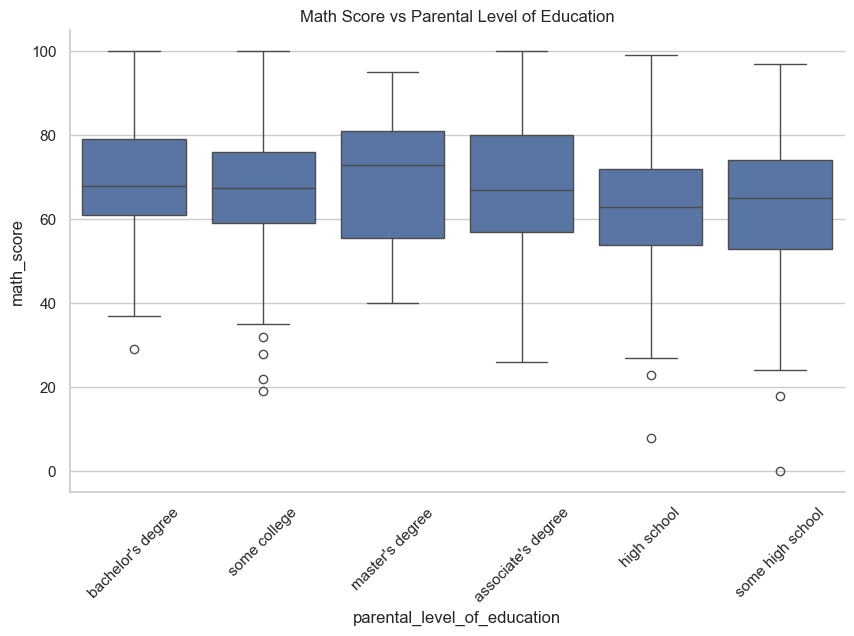

In [ ]:
#
plt.figure(figsize=(10,6))
sns.boxplot(x='parental_level_of_education', y='math_score', data=df_performance)

plt.xticks(rotation=45)
plt.title('Math Score vs Parental Level of Education')
plt.show()

<Axes: xlabel='reading_score', ylabel='writing_score'>

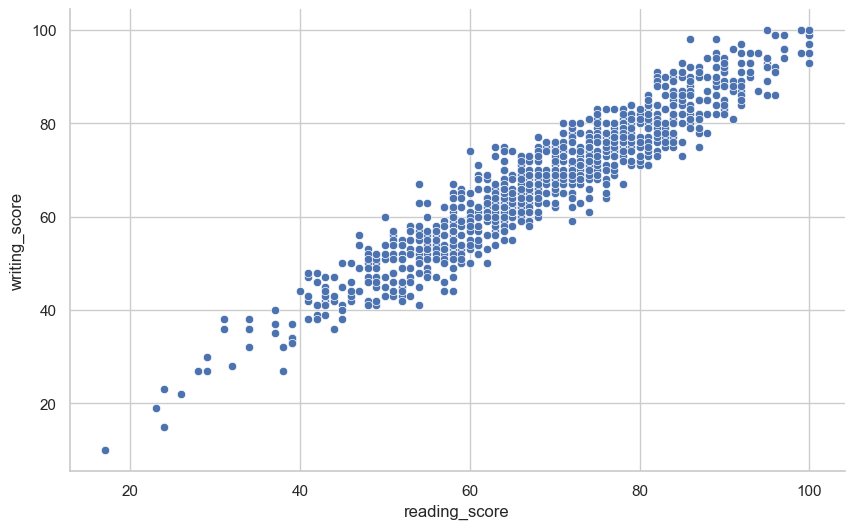

In [ ]:
#
sns.scatterplot(x=df_performance['reading_score'], y=df_performance['writing_score'])

In [8]:
prop = df_performance.groupby('gender')['test_preparation_course'].value_counts(normalize=True).unstack()

<Axes: xlabel='gender'>

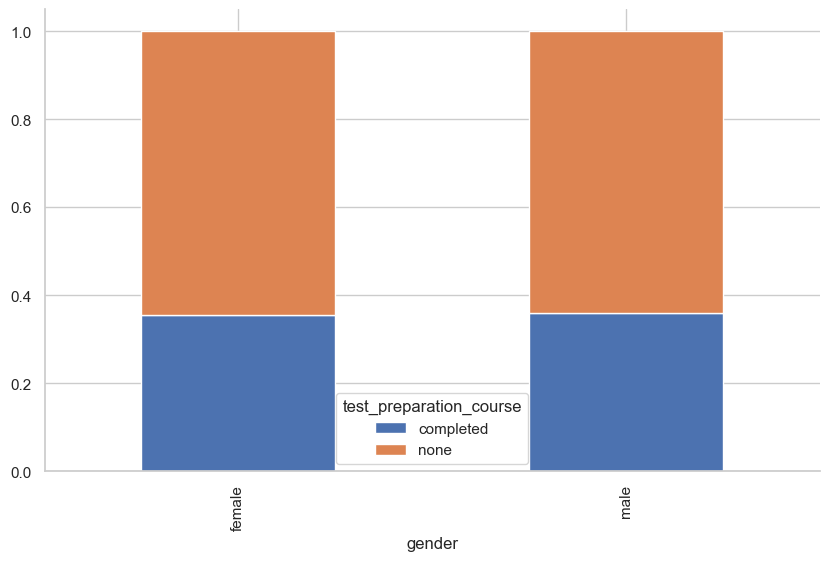

In [9]:
prop.plot(kind='bar', stacked=True)

<Axes: xlabel='gender', ylabel='count'>

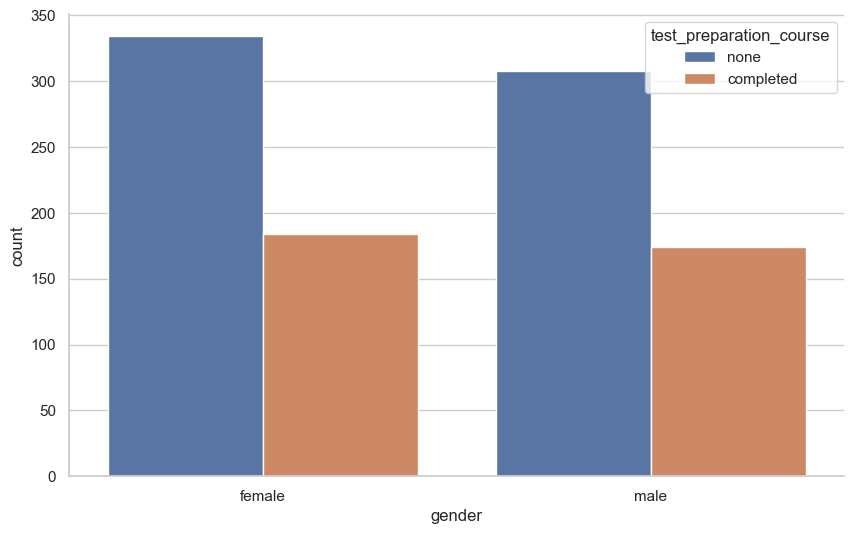

In [10]:
sns.countplot(x='gender', hue='test_preparation_course', data=df_performance)

In [11]:
df_performance['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

In [12]:
df_performance['race_ethnicity']

0      group B
1      group C
2      group B
3      group A
4      group C
        ...   
995    group E
996    group C
997    group C
998    group D
999    group D
Name: race_ethnicity, Length: 1000, dtype: object

<Axes: xlabel='race_ethnicity'>

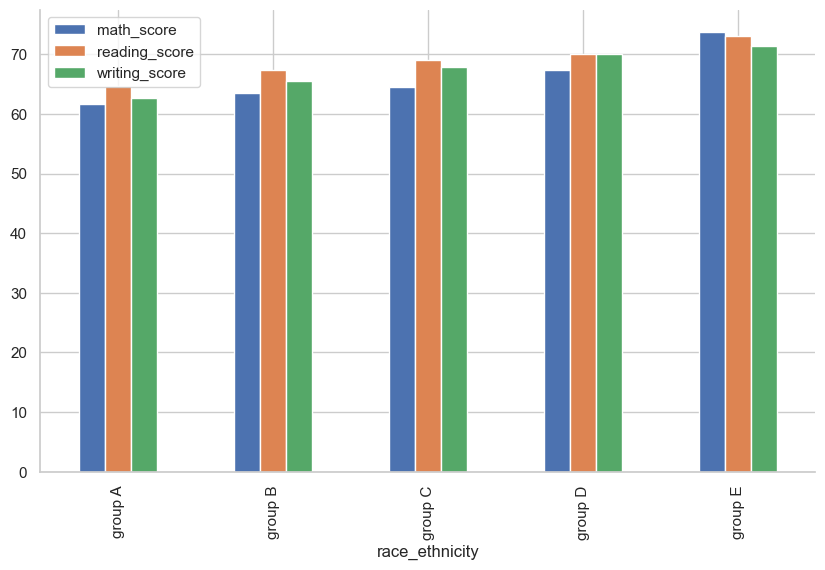

In [13]:
means = df_performance.groupby('race_ethnicity')[['math_score', 'reading_score', 'writing_score']].mean()
means.plot(kind='bar', figsize=(10,6))

In [14]:
#Começa em 60 inves de 0

C:\Users\d6684\AppData\Local\Temp\ipykernel_16864\4344859.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])


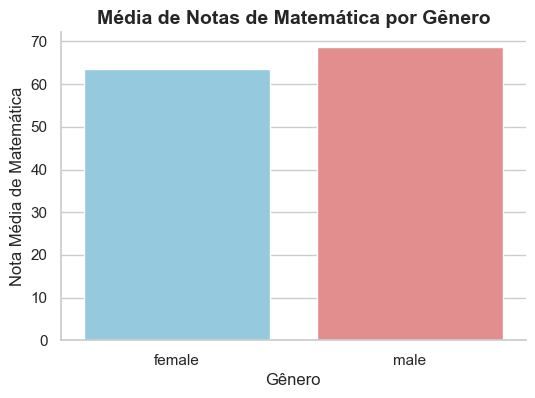

In [15]:
# Dados para o Desafio 2.1
df_gender_math = df_performance.groupby("gender")["math_score"].mean().reset_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])
ax.set_ylim(bottom=0) # Eixo Y começando alto
ax.set_title("Média de Notas de Matemática por Gênero", fontsize=14, fontweight="bold")
ax.set_xlabel("Gênero")
ax.set_ylabel("Nota Média de Matemática")
plt.show()

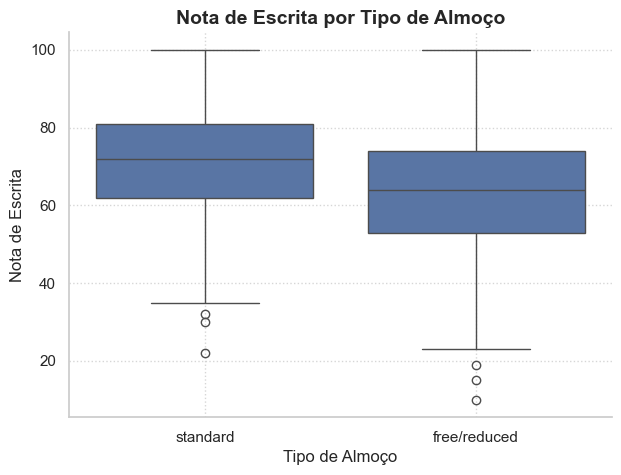

In [16]:
# Dados para o Desafio 2.2
plt.figure(figsize=(7, 5))
ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance)
ax.set_title("Nota de Escrita por Tipo de Almoço", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de Almoço")
ax.set_ylabel("Nota de Escrita")
ax.grid(True, linestyle=":", alpha=0.8) # Grade pesada
plt.show()

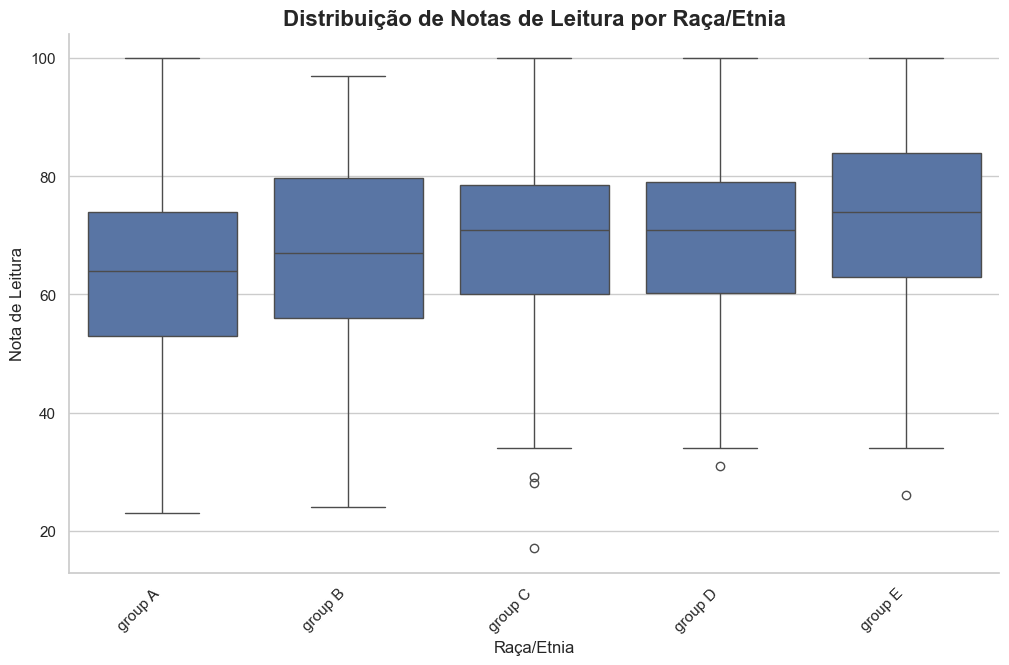

In [17]:
# Dados para o Desafio 2.3
plt.figure(figsize=(12, 7))
order = sorted(df_performance["race_ethnicity"].unique())
sns.boxplot(x="race_ethnicity", y="reading_score", data=df_performance,order=order)
plt.title("Distribuição de Notas de Leitura por Raça/Etnia", fontsize=16, fontweight="bold")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota de Leitura")
plt.xticks(rotation=45, ha='right')

plt.show()

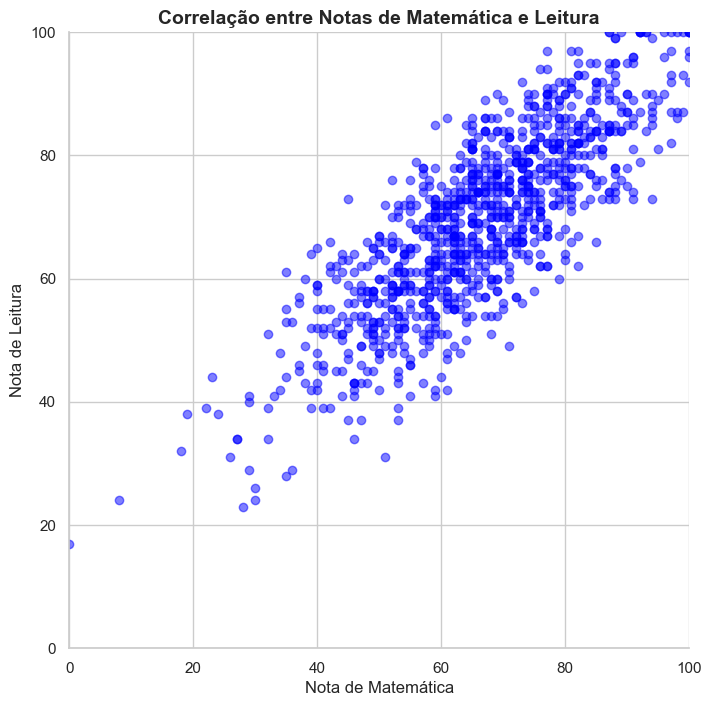

In [18]:
# Dados para o Desafio 2.4
plt.figure(figsize=(8, 8))
plt.scatter(x=df_performance["math_score"], y=df_performance["reading_score"], alpha=0.5, color="blue")
plt.title("Correlação entre Notas de Matemática e Leitura", fontsize=14, fontweight="bold")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota de Leitura")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

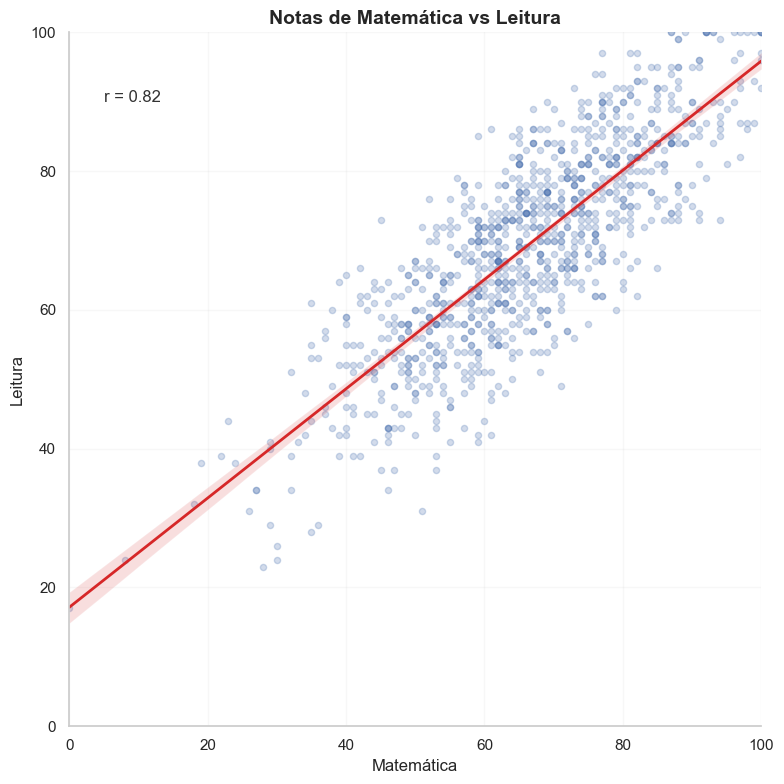

In [22]:


plt.figure(figsize=(8, 8))

sns.regplot(
    x=df_performance["math_score"],
    y=df_performance["reading_score"],
    scatter_kws={
        "alpha": 0.25,
        "s": 20,
        "color": "#4C72B0"
    },
    line_kws={
        "color": "#D62728",
        "linewidth": 2
    }
)

plt.title("Notas de Matemática vs Leitura", fontsize=14, weight="bold")
plt.xlabel("Matemática")
plt.ylabel("Leitura")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.grid(alpha=0.15)

# correlação
corr = df_performance["math_score"].corr(df_performance["reading_score"])
plt.text(5, 90, f"r = {corr:.2f}", fontsize=12, color="#333")

plt.tight_layout()
plt.show()

(0.0, 100.0)

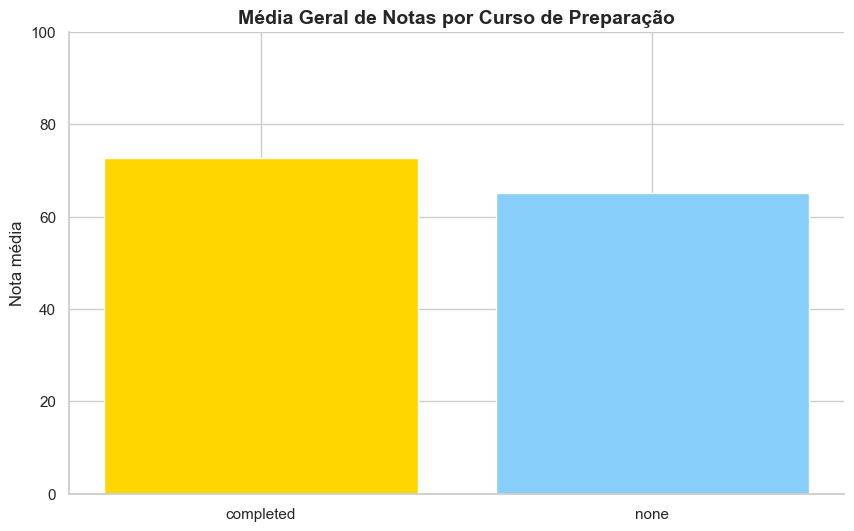

In [ ]:
# Dados para o Desafio 2.5
#Graficos de barra são mais dificeis de se ver pequenas mudanças, já que o ser humano tem mais dificuldade em notar angulos se comaprado com a altura
plt.bar(
    df_prep_course["test_preparation_course"],
    df_prep_course["overall_average_score"],
    color=["gold", "lightskyblue"]
)

plt.title("Média Geral de Notas por Curso de Preparação", fontsize=14, fontweight="bold")
plt.ylabel("Nota média")

plt.ylim(0, 100)
